# Проверка статистических гипотез о процентных долях

### Выбор теста

| Задача | Тест |
|---|---|
| Среднее против конкретного числа | Одновыборочный t-тест |
| Средние двух независимых групп | t-тест для независимых выборок |
| Средние до/после | Парный t-тест |
| ✅ Одна доля против константы | Z-тест для доли |
| ✅ Две доли | Z-тест для двух долей |
| Связь категориальных переменных | Хи-квадрат |
| Две независимые группы без нормальности | Манн–Уитни |
| Две связанные группы без нормальности | Уилкоксон |

## Проверка гипотезы о доле

Используется, когда нас интересует доля объектов с некоторым признаком.

**Пример задачи**

Из 200 пользователей 90 оформили подписку. Проверим, отличается ли доля от 40%.

In [1]:
from statsmodels.stats.proportion import proportions_ztest

Исходные данные:

In [2]:
count = 90
nobs = 200
p_0 = 0.40

alpha = 0.05

Стат. тест: 

In [3]:
z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    value=p_0
)

print(f"z-статистика: {z_stat:.3f}")
print(f"p-value: {p_value:.5f}")

z-статистика: 1.421
p-value: 0.15522


**Интерпретация**

In [4]:
if p_value <= alpha:
    print("Доля статистически значимо отличается от заданного значения")
else:
    print("Нет оснований считать, что доля отличается от заданного значения")

Нет оснований считать, что доля отличается от заданного значения


## Визуализация

In [7]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

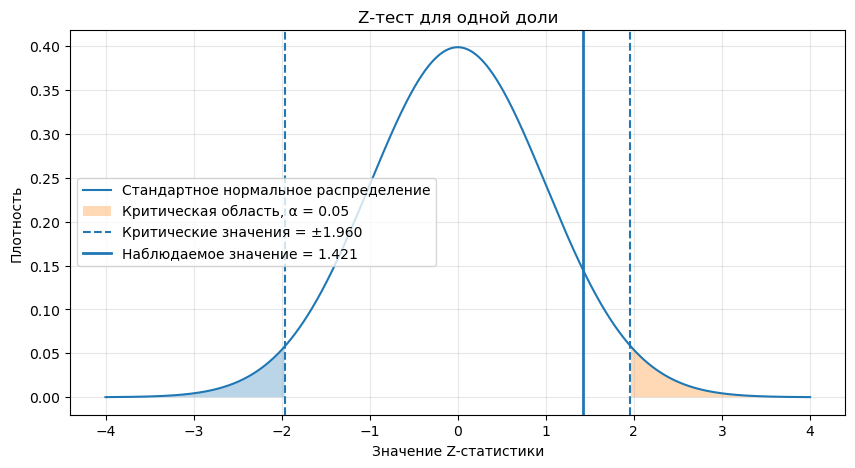

In [8]:
critical_value = stats.norm.ppf(1 - alpha / 2)

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(10, 5))

plt.plot(x, y, label="Стандартное нормальное распределение")

plt.fill_between(
    x[x <= -critical_value],
    stats.norm.pdf(x[x <= -critical_value]),
    alpha=0.3
)

plt.fill_between(
    x[x >= critical_value],
    stats.norm.pdf(x[x >= critical_value]),
    alpha=0.3,
    label=f"Критическая область, α = {alpha}"
)

plt.axvline(
    -critical_value,
    linestyle="--",
    label=f"Критические значения = ±{critical_value:.3f}"
)

plt.axvline(
    critical_value,
    linestyle="--"
)

plt.axvline(
    z_stat,
    linewidth=2,
    label=f"Наблюдаемое значение = {z_stat:.3f}"
)

plt.title("Z-тест для одной доли")
plt.xlabel("Значение Z-статистики")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Проверка равенства двух долей

Используется, когда нужно сравнить доли в двух группах.

**Пример задачи**

В первой группе подписку оформили 90 из 200 пользователей. Во второй группе — 70 из 180 пользователей. Нужно понять, различается ли конверсия в подписку в двух группах.

In [9]:
counts = np.array([90, 70])
nobs = np.array([200, 180])

alpha = 0.05

Стат. тест: 

In [10]:
z_stat, p_value = proportions_ztest(
    count=counts,
    nobs=nobs
)

print(f"z-статистика: {z_stat:.3f}")
print(f"p-value: {p_value:.5f}")

z-статистика: 1.205
p-value: 0.22831


**Интерпретация**

In [11]:
if p_value <= alpha:
    print("Доли статистически значимо различаются")
else:
    print("Нет оснований считать доли различными")

Нет оснований считать доли различными


## Визуализация

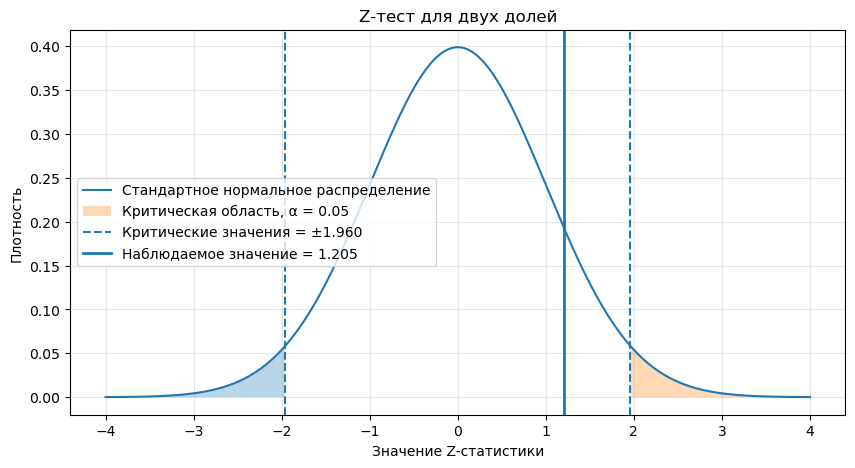

In [12]:
critical_value = stats.norm.ppf(1 - alpha / 2)

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(10, 5))

plt.plot(x, y, label="Стандартное нормальное распределение")

plt.fill_between(
    x[x <= -critical_value],
    stats.norm.pdf(x[x <= -critical_value]),
    alpha=0.3
)

plt.fill_between(
    x[x >= critical_value],
    stats.norm.pdf(x[x >= critical_value]),
    alpha=0.3,
    label=f"Критическая область, α = {alpha}"
)

plt.axvline(
    -critical_value,
    linestyle="--",
    label=f"Критические значения = ±{critical_value:.3f}"
)

plt.axvline(
    critical_value,
    linestyle="--"
)

plt.axvline(
    z_stat,
    linewidth=2,
    label=f"Наблюдаемое значение = {z_stat:.3f}"
)

plt.title("Z-тест для двух долей")
plt.xlabel("Значение Z-статистики")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)

plt.show()